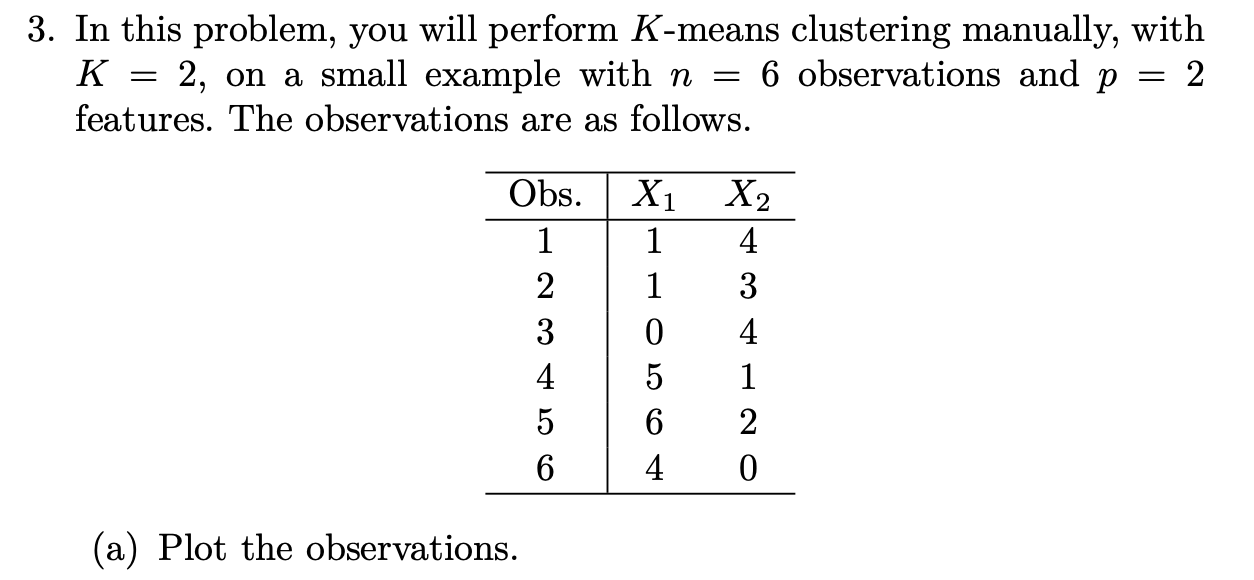

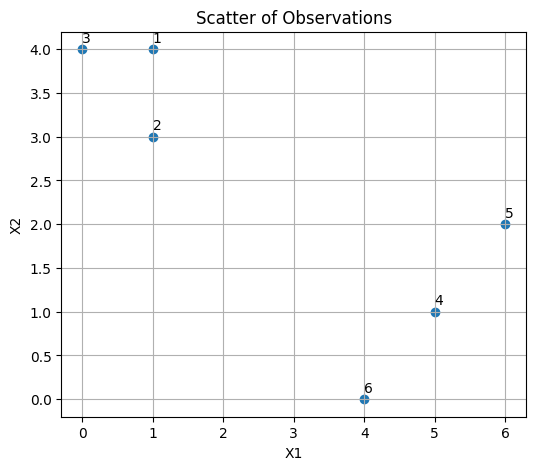

In [82]:
import matplotlib.pyplot as plt
points = {1:(1,4), 2:(1,3), 3:(0,4), 4:(5,1), 5:(6,2), 6:(4,0)}
X = np.array([points[i] for i in range(1,7)], float)

plt.figure(figsize=(6,5))
plt.scatter([p[0] for p in points.values()],
            [p[1] for p in points.values()])
for i,(x,y) in points.items():
    plt.annotate(str(i),(x,y), textcoords="offset points", xytext=(0,5))
plt.title("Scatter of Observations")
plt.xlabel("X1"); plt.ylabel("X2"); plt.grid(True)
plt.show()

(b) Randomly assign a cluster label to each observation. You can use
the np.random.choice() function to do this. Report the cluster
labels for each observation.

In [83]:
import numpy as np
labels = np.random.choice([1, 2], size=6)  # random clustering

for i, c in zip(obs, labels):
    print(f"Obs {i}: Cluster {c}")

Obs 1: Cluster 2
Obs 2: Cluster 1
Obs 3: Cluster 2
Obs 4: Cluster 1
Obs 5: Cluster 1
Obs 6: Cluster 2


(c) Compute the centroid for each cluster.

In [84]:
for k in [1, 2]:
    centroid = X[labels == k].mean(axis=0)
    print(f"Cluster {k} centroid = ({centroid[0]:.3f}, {centroid[1]:.3f})")


Cluster 1 centroid = (4.000, 2.000)
Cluster 2 centroid = (1.667, 2.667)


(d) Assign each observation to the centroid to which it is closest, in
terms of Euclidean distance. Report the cluster labels for each
observation.

In [85]:
def assign_labels(X, centroids):
    new_labels = np.empty(len(X), dtype=int)
    for i, x in enumerate(X):
        d1 = np.linalg.norm(x - centroids[1])
        d2 = np.linalg.norm(x - centroids[2])
        new_labels[i] = 1 if d1 <= d2 else 2
        print(f"Obs {i+1}: d1={d1:.3f}, d2={d2:.3f} → Cluster {new_labels[i]}")
    return new_labels

new_labels = assign_labels(X, centroids)

Obs 1: d1=5.000, d2=0.471 → Cluster 2
Obs 2: d1=4.472, d2=0.745 → Cluster 2
Obs 3: d1=5.831, d2=0.745 → Cluster 2
Obs 4: d1=0.000, d2=5.088 → Cluster 1
Obs 5: d1=1.414, d2=5.588 → Cluster 1
Obs 6: d1=1.414, d2=4.955 → Cluster 1


(e) Repeat (c) and (d) until the answers obtained stop changing.

print("Distances:\n", distances)
print("\nNew cluster labels:", new_labels)

In [86]:
def kmeans_step(X, labels):
    centroids = {k: X[labels == k].mean(axis=0) for k in [1, 2]}
    new_labels = assign_labels(X, centroids)
    return new_labels, centroids

max_iter = 20
it = 0
while it < max_iter:
    it += 1
    print(f"\nIteration {it}")
    labels_prev = labels.copy()
    labels, centroids = kmeans_step(X, labels_prev)
    if np.array_equal(labels, labels_prev):
        break

print("\nFinal labels (Obs 1..6):", labels.tolist())
print(f"Final d1 = ({centroids[1][0]:.3f}, {centroids[1][1]:.3f})")
print(f"Final d2 = ({centroids[2][0]:.3f}, {centroids[2][1]:.3f})")
print("\nConverged.")



Iteration 1
Obs 1: d1=3.606, d2=1.491 → Cluster 2
Obs 2: d1=3.162, d2=0.745 → Cluster 2
Obs 3: d1=4.472, d2=2.134 → Cluster 2
Obs 4: d1=1.414, d2=3.727 → Cluster 1
Obs 5: d1=2.000, d2=4.384 → Cluster 1
Obs 6: d1=2.000, d2=3.543 → Cluster 1

Iteration 2
Obs 1: d1=5.000, d2=0.471 → Cluster 2
Obs 2: d1=4.472, d2=0.745 → Cluster 2
Obs 3: d1=5.831, d2=0.745 → Cluster 2
Obs 4: d1=0.000, d2=5.088 → Cluster 1
Obs 5: d1=1.414, d2=5.588 → Cluster 1
Obs 6: d1=1.414, d2=4.955 → Cluster 1

Final labels (Obs 1..6): [2, 2, 2, 1, 1, 1]
Final d1 = (5.000, 1.000)
Final d2 = (0.667, 3.667)

Converged.


(f) In your plot from (a), color the observations according to the
cluster labels obtained.

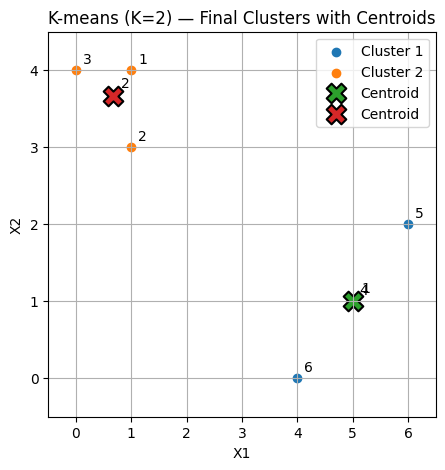

In [87]:
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
for k in [1, 2]:
    idx = np.where(labels == k)[0]
    plt.scatter(X[idx,0], X[idx,1], label=f"Cluster {k}")
    for i in idx:
        plt.annotate(str(i+1), (X[i,0], X[i,1]), textcoords="offset points", xytext=(5,5))

# centroid
for k in [1, 2]:
    cx, cy = centroids[k]
    plt.scatter([cx], [cy], marker='X', s=200, linewidths=1.5, edgecolors='k', label=f"Centroid")
    plt.annotate(f"{k}", (cx, cy), textcoords="offset points", xytext=(6,6))

plt.title("K-means (K=2) — Final Clusters with Centroids")
plt.xlabel("X1"); plt.ylabel("X2"); plt.grid(True)
plt.legend(); plt.xlim(-0.5, 6.5); plt.ylim(-0.5, 4.5)
plt.show()
